# TITANIC

In [75]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [76]:
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")

In [77]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [78]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## NOTE:
    -survival	Survival	0 = No, 1 = Yes
    -pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
    -sex	Sex	
    -Age	Age in years	
    -sibsp	# of siblings / spouses aboard the Titanic	
    -parch	# of parents / children aboard the Titanic	
    -ticket	Ticket number	
    -fare	Passenger fare	
    -cabin	Cabin number	
    -embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [79]:
#preview data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
train_df.set_index(train_df.PassengerId,inplace=True)

In [81]:
test_passenger_id = test_df['PassengerId']
train_df.drop('PassengerId',axis=1,inplace=True)

In [82]:
test_df=pd.read_csv('test.csv',index_col='PassengerId')

In [83]:
test_df.tail()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


### Numerical Features
    * Continiuos
    * Discrete
    * TimeSeries
### Categorical Features
    * Nominal
    * Ordinal
    * Ratio
    * Interval

In [84]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [85]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


- Categorical: `Survived`, `Sex`, `Embarked`, `Pclass (ordinal)`, `SibSp`, `Parch`
- Numerical: (continuous) `Age`, `Fare`, (discrete) `SibSp`, `Parch`
- Mix types of data: `Ticket`, `Cabin`
- Contain Error/Typo: `Name`
- Blank or Null: `Cabin` > `Age` > `Embarked`
- Various Data Type: String, Int, Float

In [86]:
train_df['Survived']=train_df['Survived'].astype('category') 

In [87]:
features=["Pclass","Sex","SibSp","Parch","Embarked"]
def convert_cat(df,features):
    for feature in features:
        df[feature]=df[feature].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)

In [88]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    object  
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    object  
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    object  
 10  Embarked  889 non-null    category
dtypes: category(6), float64(2), object(3)
memory usage: 48.2+ KB


### Distrubtion of numerical feature values across the sample

In [89]:
train_df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


### Distrubtion of Caterogical Features

In [90]:
train_df.describe(include=['category'])

,Survived,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


## 3. Exploratory Data Analysis (EDA)

### Correlating categorical features

- Categorical: `Survived`, `Sex`, `Embarked`, `Pclass` (ordinal), `SibSp`, `Parch`

**Target Variable:** `Survived`

In [91]:
train_df["Survived"].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [92]:
train_df["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


### SEX

In [93]:
train_df["Sex"].value_counts().to_frame()

,count
Sex,
male,577
female,314


In [94]:
train_df["Sex"].value_counts(normalize=True).to_frame()

,proportion
Sex,
male,0.647587
female,0.352413


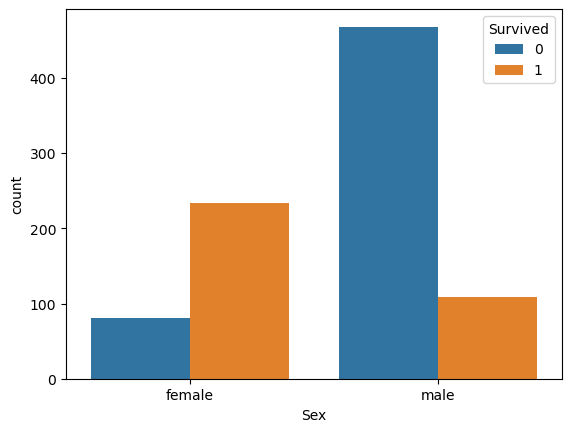

In [95]:
sns.countplot(data=train_df,x='Sex',hue='Survived');

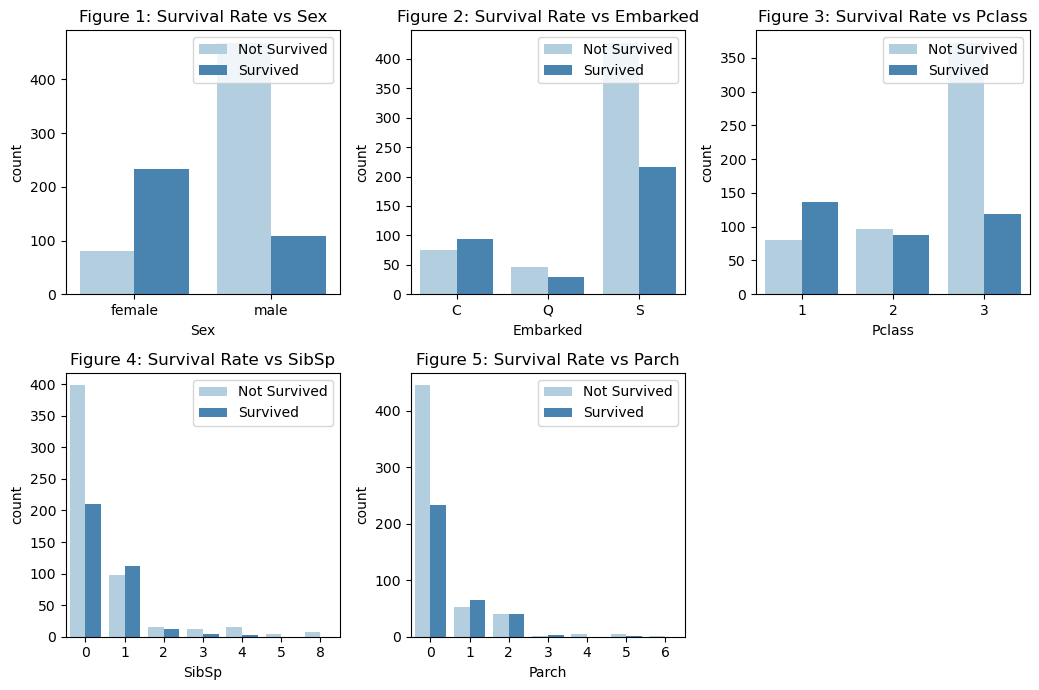

In [96]:
cols = ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']

n_rows = 2
n_cols = 3

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))

for r in range(0, n_rows):
    for c in range(0, n_cols):
        i = r * n_cols + c  # index to loop through list "cols"

        if i < len(cols):
            ax_i = ax[r, c]

            sns.countplot(
                data=train_df,
                x=cols[i],
                hue="Survived",
                palette="Blues",
                ax=ax_i
            )

            ax_i.set_title(f"Figure {i+1}: Survival Rate vs {cols[i]}")
            ax_i.legend(
                title='',
                loc='upper right',
                labels=['Not Survived', 'Survived']
            )
ax.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

## EDA For Numerical Features

### AGE

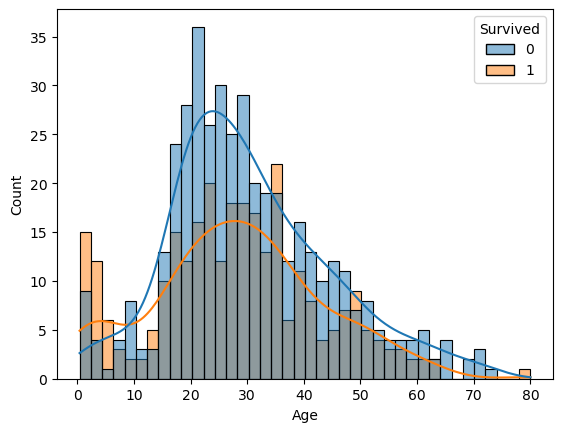

In [97]:
sns.histplot(data=train_df,x='Age',hue='Survived',bins=40,kde=True);

## Fare

In [98]:
train_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

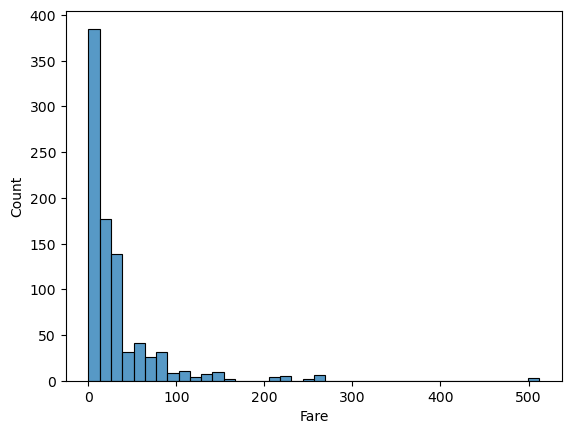

In [99]:
sns.histplot(data=train_df,x='Fare',bins=40);

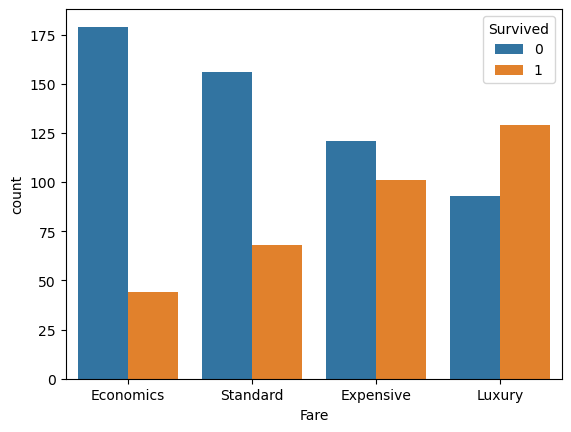

In [100]:
fare_categories=['Economics','Standard','Expensive','Luxury']
pd.qcut(train_df['Fare'],4,labels=fare_categories)

quartile_data = pd.qcut(train_df['Fare'],4,labels=fare_categories)
sns.countplot(x=quartile_data, hue=train_df['Survived']);

In [101]:
train_df['Fare']

PassengerId
1       7.2500
2      71.2833
3       7.9250
4      53.1000
5       8.0500
        ...   
887    13.0000
888    30.0000
889    23.4500
890    30.0000
891     7.7500
Name: Fare, Length: 891, dtype: float64

## Feature Engineering & Data Preprocessing

In [102]:
train_df['Name'].tail(10)

PassengerId
882                          Markun, Mr. Johann
883                Dahlberg, Miss. Gerda Ulrika
884               Banfield, Mr. Frederick James
885                      Sutehall, Mr. Henry Jr
886        Rice, Mrs. William (Margaret Norton)
887                       Montvila, Rev. Juozas
888                Graham, Miss. Margaret Edith
889    Johnston, Miss. Catherine Helen "Carrie"
890                       Behr, Mr. Karl Howell
891                         Dooley, Mr. Patrick
Name: Name, dtype: object

## NAME -> TITLE

In [103]:
import re

def extract_title(name):
    p = re.compile(r",\s*([^\.]+)\.")
    return p.search(name).group(1).strip()

train_df['Title'] = train_df['Name'].apply(lambda name: extract_title(name))

In [104]:
train_df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [105]:
test_df['Title'] = test_df['Name'].apply(lambda name: extract_title(name))
test_df['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [106]:
def group_title(title):
    if title in ['Mr','Mrs','Miss','Master']:
        return title
    elif title == "Ms":
        return "Miss"
    else:
        return "Others"
train_df['Title']=train_df['Title'].apply(lambda title : group_title(title))
test_df['Title']=test_df['Title'].apply(lambda title : group_title(title))

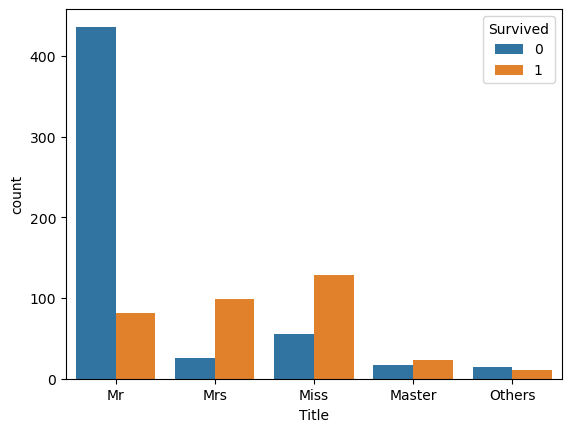

In [107]:
sns.countplot(data=train_df,x='Title',hue='Survived');

## Family
- `SibSp`, `Parch`

In [108]:
train_df['Family_Size']=train_df['SibSp'].astype('int') + train_df['Parch'].astype('int') + 1
test_df['Family_Size']=test_df['SibSp'].astype('int') + test_df['Parch'].astype('int') + 1


In [109]:
train_df['Family_Cat']=pd.cut(train_df['Family_Size'],bins=[0,1,4,6,20],labels=['Solo','Small','Medium','Large'])
test_df['Family_Cat']=pd.cut(test_df['Family_Size'],bins=[0,1,4,6,20],labels=['Solo','Small','Medium','Large'])

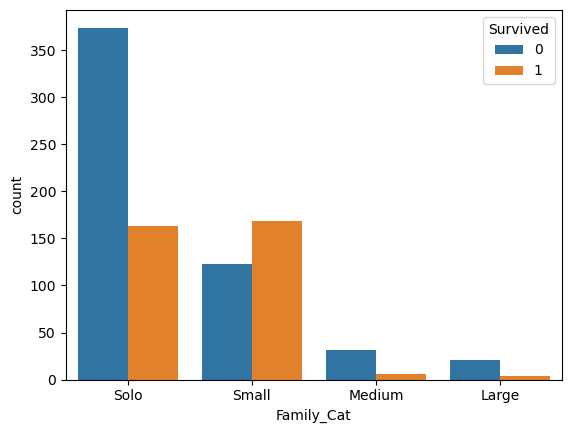

In [110]:
sns.countplot(data=train_df,x='Family_Cat',hue='Survived');

### Data Preprocessing

In [111]:
num_features=['Age','Fare']
cat_features=['Sex','Pclass','Embarked','Title','Family_Cat']
feature_cols=num_features+cat_features
print(feature_cols)

['Age', 'Fare', 'Sex', 'Pclass', 'Embarked', 'Title', 'Family_Cat']


In [112]:
def display_missing(df,feature_cols):
    n_rows=df.shape[0]
    for col in feature_cols:
        missing_count=df[col].isnull().sum()
        if missing_count>0:
            print(f"{col} has {missing_count*100/n_rows:.2f}% missing values.")
display_missing(train_df,feature_cols)
display_missing(test_df,feature_cols)

Age has 19.87% missing values.
Embarked has 0.22% missing values.
Age has 20.57% missing values.
Fare has 0.24% missing values.


### Filling Missing Values

### Age
- Filling missing values with median of whole dataset

In [113]:
age_by_sex_pclass=train_df.groupby(['Sex','Pclass']).median(['Age'])['Age']

C:\Users\vtkhu\AppData\Local\Temp\ipykernel_28304\105450153.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_sex_pclass=train_df.groupby(['Sex','Pclass']).median(['Age'])['Age']


In [114]:
age_by_sex_pclass

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [115]:
train_df['Age'] = train_df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

test_df['Age'] = test_df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\vtkhu\AppData\Local\Temp\ipykernel_28304\2435471823.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df['Age'] = train_df.groupby(['Sex', 'Pclass'])['Age'].transform(
C:\Users\vtkhu\AppData\Local\Temp\ipykernel_28304\2435471823.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df['Age'] = test_df.groupby(['Sex', 'Pclass'])['Age'].transform(


In [116]:
train_df.groupby(['Sex','Pclass'])['Age'].apply(lambda x: x.fillna(x.median()))

C:\Users\vtkhu\AppData\Local\Temp\ipykernel_28304\1026649559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Sex','Pclass'])['Age'].apply(lambda x: x.fillna(x.median()))


Sex     Pclass  PassengerId
female  1       2              38.0
                4              35.0
                12             58.0
                32             35.0
                53             49.0
                               ... 
male    3       878            19.0
                879            25.0
                882            33.0
                885            25.0
                891            32.0
Name: Age, Length: 891, dtype: float64

In [117]:
display_missing(train_df, feature_cols)
display_missing(test_df, feature_cols)

Embarked has 0.22% missing values.
Fare has 0.24% missing values.


In [118]:
X = train_df[feature_cols]
y = train_df['Survived']

X_test = test_df[feature_cols] 

In [119]:
#preprocess pipleline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())
                ])
cat_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))
                                ])

In [120]:
preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,num_features),('cat',cat_transformer,cat_features)  
])

In [121]:
preprocessor.fit(X)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [122]:
X=preprocessor.transform(X) # X -> X_train, X_val

In [123]:
X_test=preprocessor.transform(X_test)

### MODEL TRAINING

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2)

In [126]:
X_train.shape, X_val.shape

((712, 19), (179, 19))

In [127]:
X_test.shape

(418, 19)

In [128]:
# binary classifications
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,classification_report,confusion_matrix

In [129]:
log_req = LogisticRegression(solver='liblinear',max_iter=1000)
log_req.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [130]:
log_req.score(X_val,y_val)

0.8603351955307262

In [131]:
y_pred=log_req.predict(X_val)

In [132]:
precision_score(y_val,y_pred),recall_score(y_val,y_pred)

(0.8305084745762712, 0.765625)

In [133]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       115
           1       0.83      0.77      0.80        64

    accuracy                           0.86       179
   macro avg       0.85      0.84      0.85       179
weighted avg       0.86      0.86      0.86       179



In [134]:
poly=PolynomialFeatures(degree=2)
poly_features_X_train=poly.fit_transform(X_train)
poly_features_X_val=poly.transform(X_val)

In [135]:
poly_log_req=LogisticRegression(solver='liblinear',max_iter=1000)
poly_log_req.fit(poly_features_X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [136]:
poly_log_req.score(poly_features_X_val,y_val)

0.8379888268156425

In [137]:
#Decision Tree
decision_tree=DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state=2022)
decision_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2022
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [138]:
decision_tree.score(X_val,y_val)

0.8324022346368715

### Cross-validation

In [139]:
from sklearn.model_selection import cross_val_score

In [140]:
log_req_cv=LogisticRegression(solver='liblinear',max_iter=1000)
dt_cv=DecisionTreeClassifier(criterion='entropy',max_depth=8,random_state=2022)
lr_scores=cross_val_score(log_req_cv,X,y,scoring='accuracy',cv=5)

In [141]:
lr_scores.mean(),lr_scores.std()

(np.float64(0.826031008725127), np.float64(0.020466357172416235))

In [142]:
dt_scores=cross_val_score(dt_cv,X,y,scoring='accuracy',cv=5)

In [143]:
dt_scores.mean(),dt_scores.std()

(np.float64(0.8069801016885318), np.float64(0.014586754299604428))

### Baseline Model Comparision

In [144]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,ExtraTreesClassifier,AdaBoostClassifier
seed=2026
models=[
    LinearSVC(random_state=2026),
    SVC(random_state=2026),
    KNeighborsClassifier(metric='minkowski',p=2),
    LogisticRegression(solver='liblinear',max_iter=1000),
    DecisionTreeClassifier(random_state=seed),
    RandomForestClassifier(random_state=seed),
    ExtraTreesClassifier(),
    AdaBoostClassifier()
]

In [145]:
from sklearn.model_selection import StratifiedKFold

def generate_baseline_results(models, X, y, metrics, cv=5, plot_results=False):
    # define k-fold
    kfold = StratifiedKFold(cv, shuffle=True, random_state=seed)
    entries = []

    for model in models:
        model_name = model.__class__.__name__
        scores = cross_val_score(model, X, y, scoring=metrics, cv=kfold)

        for fold_idx, score in enumerate(scores):
            entries.append((model_name, fold_idx, score))

    cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_id', 'accuracy_score'])

    if plot_results:
        sns.boxplot(x='model_name', y='accuracy_score', data=cv_df, color='lightblue', showmeans=True)
        plt.title("Boxplot of Base-Line Model Accuracy using 5-fold cross-validation")
        plt.xticks(rotation=45)
        plt.show()

    # Summary result
    mean = cv_df.groupby('model_name')['accuracy_score'].mean()
    std = cv_df.groupby('model_name')['accuracy_score'].std()

    baseline_results = pd.concat([mean, std], axis=1, ignore_index=True)
    baseline_results.columns = ['Mean', 'Standard Deviation']

    # sort by accuracy
    baseline_results.sort_values(by=['Mean'], ascending=False, inplace=True)

    return baseline_results
generate_baseline_results(models,X,y,metrics='accuracy',cv=5,plot_results=False)

,Mean,Standard Deviation
model_name,,
SVC,0.829339,0.036358
LinearSVC,0.828203,0.040875
LogisticRegression,0.827079,0.040646
KNeighborsClassifier,0.821518,0.021070
AdaBoostClassifier,0.816961,0.054190
RandomForestClassifier,0.813703,0.013213
DecisionTreeClassifier,0.791243,0.023986
ExtraTreesClassifier,0.787866,0.026583


In [147]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

best_model = SVC()
best_model.fit(X_scaled, y)

test_pred = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'PassengerId': test_passenger_id,
    'Survived': test_pred
})

submission.to_csv('submission.csv', index=False)